In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('46400_AS05_Loads_stats_Spring2026.csv', sep=';', skiprows=[1],
                  parse_dates=['rname'], date_parser=lambda x: pd.to_datetime(x, format='%Y%m%d%H%M', errors='coerce'))
df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_2368\2035159915.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_csv('46400_AS05_Loads_stats_Spring2026.csv', sep=';', skiprows=[1],


,rname,Wsp_44m,Wsp_44m_stdev,Wdir_41m,ROT,yaw,pa,po,wsn,MyTB_mean,...,MyA1_DEL9,MyA1_DEL12,MxA1_mean,MxA1_stdev,MxA1_min,MxA1_max,MxA1_DEL3,MxA1_DEL6,MxA1_DEL9,MxA1_DEL12
0,2017-01-01 20:40:00,6.36,0.66,282.66,20.55,278.61,-1.77,175.50,6.81,-887.597,...,269.619,276.271,-211.509,47.3831,-360.007,37.0285,74.6592,142.7520,195.733,231.585
1,2017-01-01 20:50:00,6.68,0.47,283.25,20.30,278.61,-1.79,169.60,6.71,-855.687,...,266.767,272.674,-205.411,32.0547,-331.265,-118.0460,53.1841,86.3817,111.966,129.650
2,2017-01-01 21:00:00,6.24,0.46,278.10,18.60,278.61,-1.67,133.07,6.11,-690.603,...,266.548,273.040,-165.332,30.6360,-274.459,-79.2139,49.5711,80.4282,103.191,118.637
3,2017-01-01 21:20:00,6.07,0.50,280.70,18.88,278.61,-1.73,133.55,6.22,-708.469,...,267.087,273.637,-169.816,38.8028,-303.106,-82.3943,49.3179,84.2135,112.190,130.894
4,2017-01-01 21:30:00,5.90,0.47,283.28,19.25,278.61,-1.74,121.60,6.41,-684.019,...,266.315,272.631,-167.399,30.2279,-295.519,-84.0601,50.8816,84.6000,110.266,127.860


Mask as pd.Series initialized in order to account for all the filters.

In [10]:
mask = pd.Series(True, index=df.index)

report = []  # to store results of filtering steps

Plotting to check unusual data points

In [11]:
def plot_wsp_with_stdev(df):
    plt.figure(figsize=(12, 4))
    
    plt.plot(df['rname'], df["Wsp_44m"], label="Wsp_44m (mean)")
    plt.plot(df['rname'], df["Wsp_44m_stdev"], label="Wsp_44m_stdev")
    
    plt.title("Wind Speed at 44m (Mean & Std Dev)")
    plt.xlabel("Time")
    plt.ylabel("Wind Speed (m/s)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

From a first visualization, it is easy to spot some flawed values (Wsp ~ 1e7) so a filter for a maximum velocity of 30 m/s is applied.

Removed 46 rows where Wsp_44m > 30 m/s


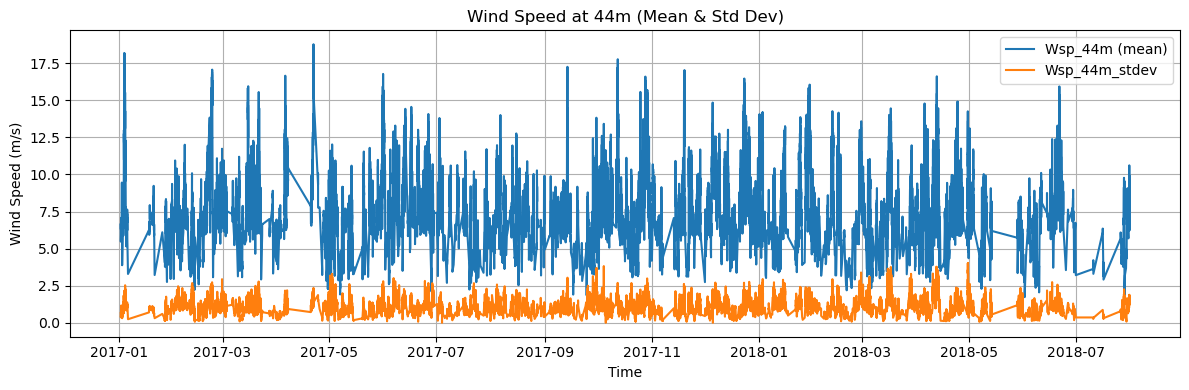

In [12]:
before = mask.sum()

wsp_mask = (df["Wsp_44m"] < 30)
mask &= wsp_mask
after = mask.sum()

print(f"Removed {len(df) - len(df[mask])} rows where Wsp_44m > 30 m/s")

removed = before - after
report.append(("wsp < 30 m/s", removed, after))

plot_wsp_with_stdev(df[mask])

In [13]:
meteo_cols = ["Wdir_41m"]  # wind direction

operational_cols = [
    "ROT",   # rotor velocity
    "yaw",
    "pa",    # pitch angle
    "po",    # active power
    "wsn"
]

def plot_columns(df, columns, title_prefix):
    for col in columns:
        if col not in df.columns:
            print(f"Skipping {col} (not found)")
            continue
        
        plt.figure(figsize=(12, 4))
        plt.plot(df['rname'], df[col])
        plt.title(f"{title_prefix}: {col}")
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

Meteorological and operational parameters plots.

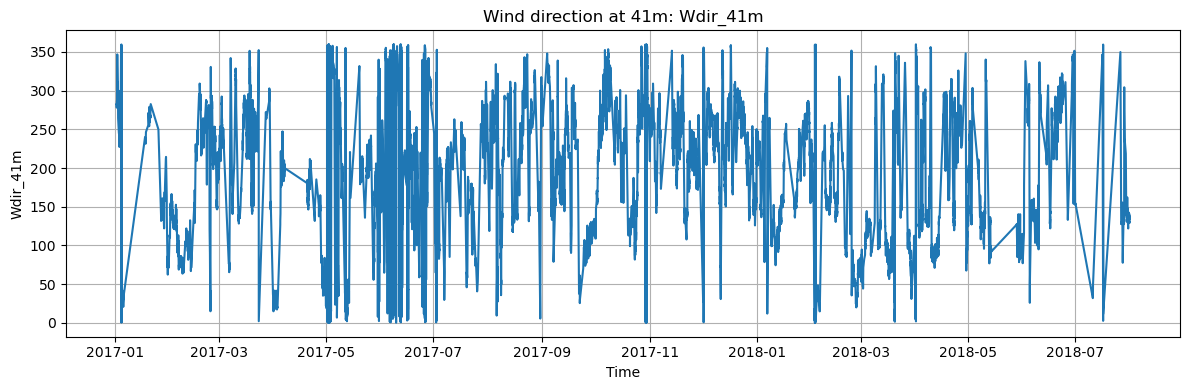

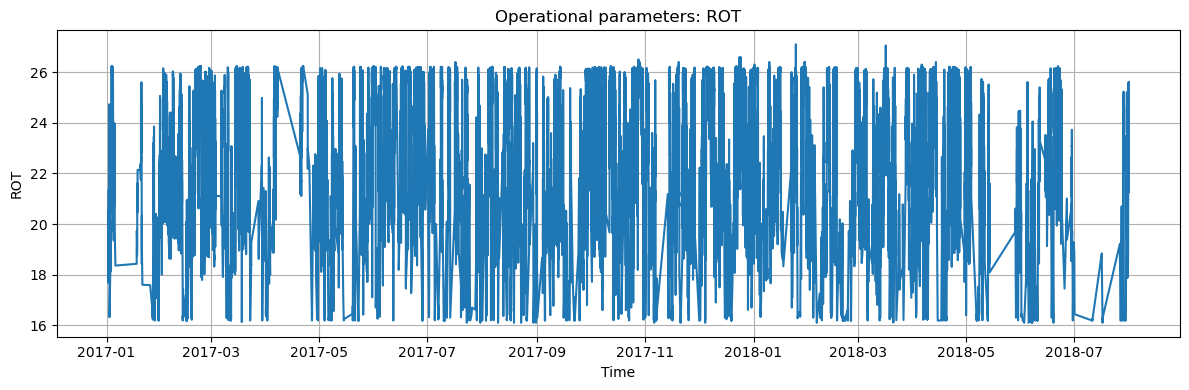

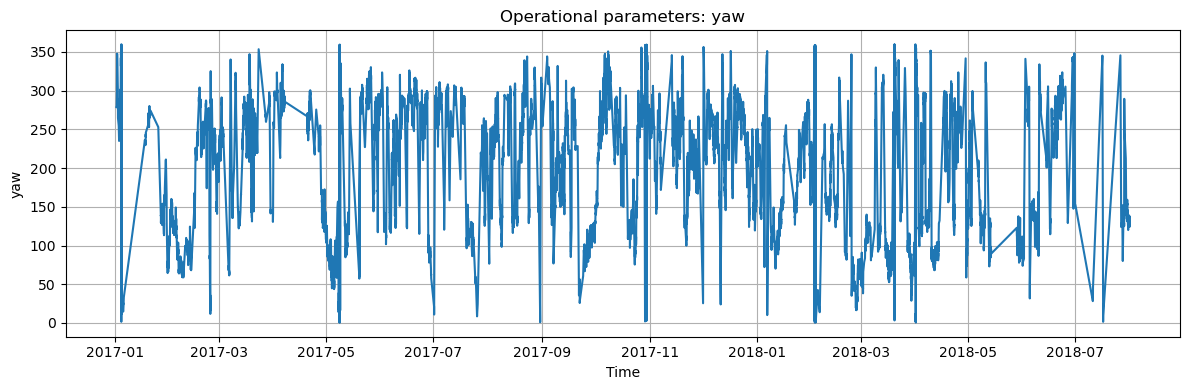

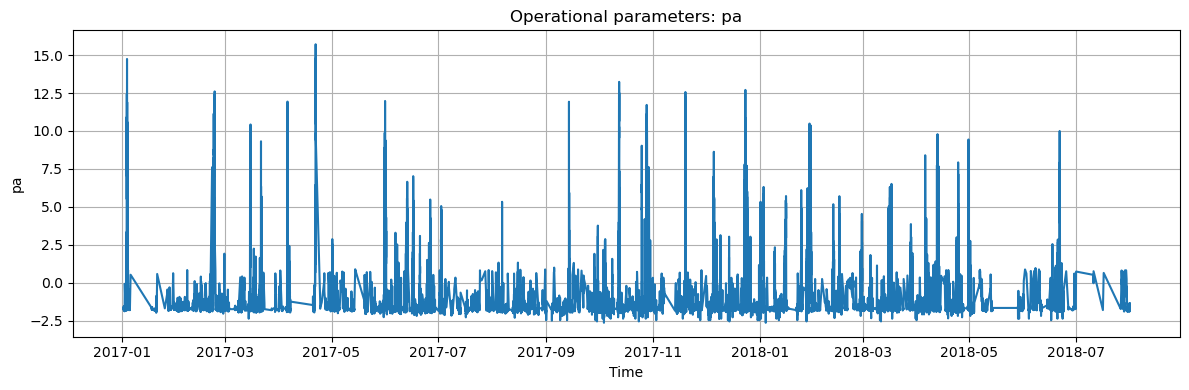

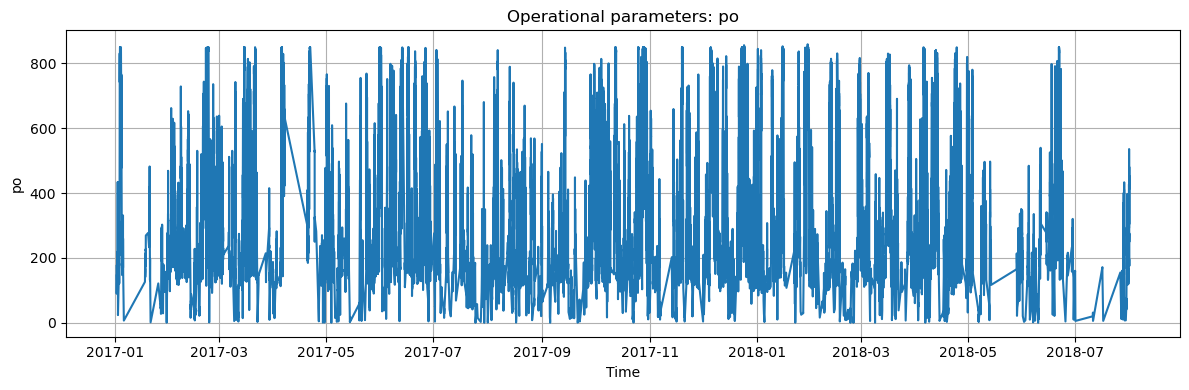

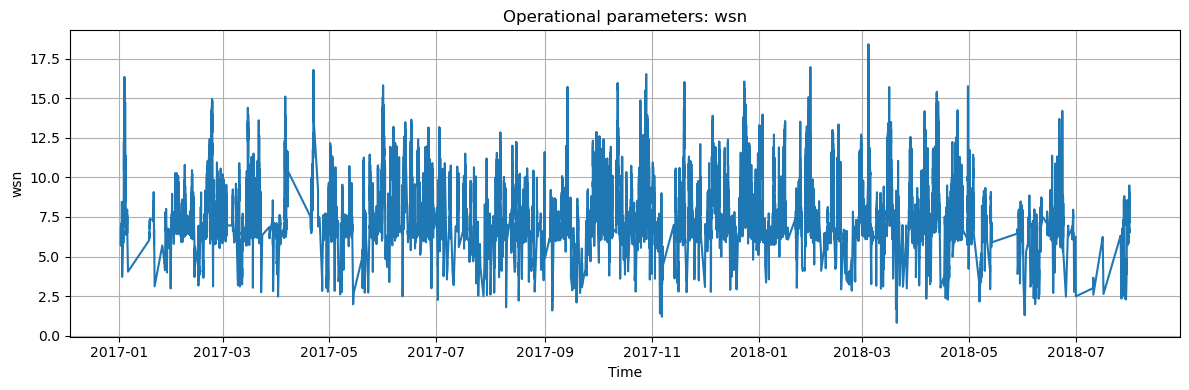

In [14]:
plot_columns(df, meteo_cols, "Wind direction at 41m")

plot_columns(df, operational_cols, "Operational parameters")

Ensuring rotor speed limits are respected.

In [15]:
before = mask.sum()

rotor_limits = ((df['ROT'] > 16) & (df['ROT'] < 26.5))
mask &= rotor_limits

after = mask.sum()
removed = before - after

report.append(("ROT speed limits (16-26.5 rpm)", removed, after))
print(f"Removed {removed} rows based on ROT limits")

Removed 7 rows based on ROT limits


Wind vane measurements between 2017-03-30 11:10 & 2017-08-08 13:50 are found to be invalid. Therefore, all the values collected in that period must be filtered out because many other measurements are direction-dependant (such as wake-free sectors and energy production in wake-free sectors, load analysis vs inflow angle) and yaw directions cannot be verified (*even because they are strictly correlated most of the times due to yaw angles being considered the "absolute" wind direction in e.g. SCADA*) although not implying wind turbine production was faulted.

In [16]:
before = mask.sum()

start = pd.Timestamp('2017-03-30 11:10')
end = pd.Timestamp('2017-08-08 13:50')

time_mask = (df['rname'] < start) | (df['rname'] > end)
mask &= time_mask

after = mask.sum()
removed = before - after

report.append(("Valid time period", removed, after))
print(f"Removed {removed} rows based on valid time period")


Removed 5052 rows based on valid time period


Valid sector is within 260 and 320 deg (320 excluded).

In [17]:
before = mask.sum()

sector_mask = (df['Wdir_41m'] >= 260) & (df['Wdir_41m'] < 320)
mask &= sector_mask

after = mask.sum()
removed = before - after

report.append(("Wind direction sector (260-320 degrees)", removed, after))
print(f"Removed {removed} rows based on wind direction sector (260-320 degrees)")

Removed 14114 rows based on wind direction sector (260-320 degrees)


In [18]:
report_df = pd.DataFrame(report, columns=["Filter", "Removed", "Remaining"])

print(report_df)

                                    Filter  Removed  Remaining
0                             wsp < 30 m/s       46      24483
1           ROT speed limits (16-26.5 rpm)        7      24476
2                        Valid time period     5052      19424
3  Wind direction sector (260-320 degrees)    14114       5310


Dropping the 'False' values to np.nan to avoid further miscalculation. 

In [19]:
final_df = df[mask].copy()
final_df.loc[~mask] = np.nan  # set removed rows to NaN for clarity
final_df # sanity check with report outcome

,rname,Wsp_44m,Wsp_44m_stdev,Wdir_41m,ROT,yaw,pa,po,wsn,MyTB_mean,...,MyA1_DEL9,MyA1_DEL12,MxA1_mean,MxA1_stdev,MxA1_min,MxA1_max,MxA1_DEL3,MxA1_DEL6,MxA1_DEL9,MxA1_DEL12
0,2017-01-01 20:40:00,6.36,0.66,282.66,20.55,278.61,-1.77,175.50,6.81,-887.597,...,269.619,276.271,-211.5090,47.3831,-360.00700,37.0285,74.6592,142.7520,195.7330,231.5850
1,2017-01-01 20:50:00,6.68,0.47,283.25,20.30,278.61,-1.79,169.60,6.71,-855.687,...,266.767,272.674,-205.4110,32.0547,-331.26500,-118.0460,53.1841,86.3817,111.9660,129.6500
2,2017-01-01 21:00:00,6.24,0.46,278.10,18.60,278.61,-1.67,133.07,6.11,-690.603,...,266.548,273.040,-165.3320,30.6360,-274.45900,-79.2139,49.5711,80.4282,103.1910,118.6370
3,2017-01-01 21:20:00,6.07,0.50,280.70,18.88,278.61,-1.73,133.55,6.22,-708.469,...,267.087,273.637,-169.8160,38.8028,-303.10600,-82.3943,49.3179,84.2135,112.1900,130.8940
4,2017-01-01 21:30:00,5.90,0.47,283.28,19.25,278.61,-1.74,121.60,6.41,-684.019,...,266.315,272.631,-167.3990,30.2279,-295.51900,-84.0601,50.8816,84.6000,110.2660,127.8600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24341,2018-06-29 02:30:00,6.96,0.59,297.81,19.46,297.41,-1.77,174.50,6.44,-445.093,...,257.020,265.557,-166.1990,38.5544,-288.80200,-82.2609,40.7678,78.0579,105.7260,123.9100
24342,2018-06-29 02:50:00,6.84,0.58,307.61,18.54,306.62,-1.72,157.74,6.08,-206.250,...,258.204,267.155,-146.8000,30.8553,-242.34300,-62.7121,40.4131,66.2236,87.9940,103.3540
24442,2018-07-28 21:00:00,1.68,0.40,304.34,16.20,272.63,0.14,13.70,3.70,163.032,...,229.071,242.102,55.4512,13.9358,-4.43002,114.6720,17.7782,37.8901,54.4215,66.0145
24443,2018-07-28 21:10:00,1.42,0.39,274.56,16.20,289.48,0.14,13.70,3.70,127.257,...,225.218,238.549,58.7726,7.7086,35.91250,80.7175,10.1262,16.0012,20.9358,24.9505


Timeseries plotting applying filters.

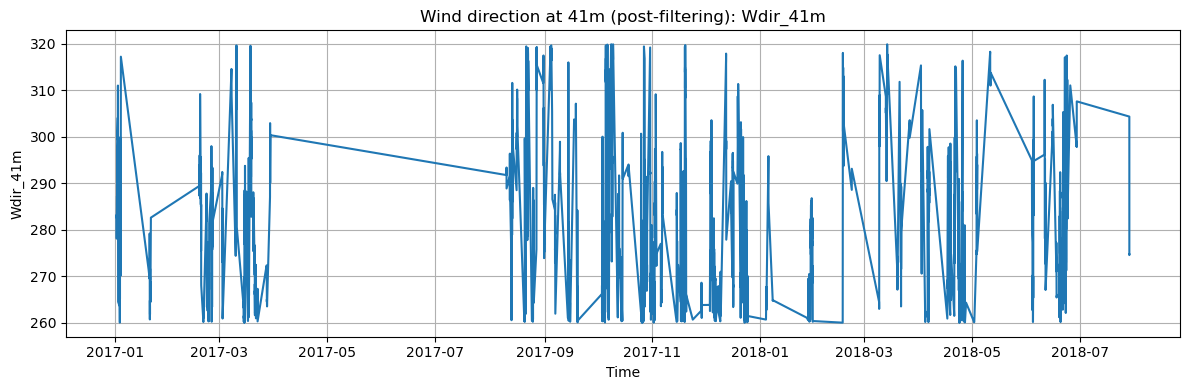

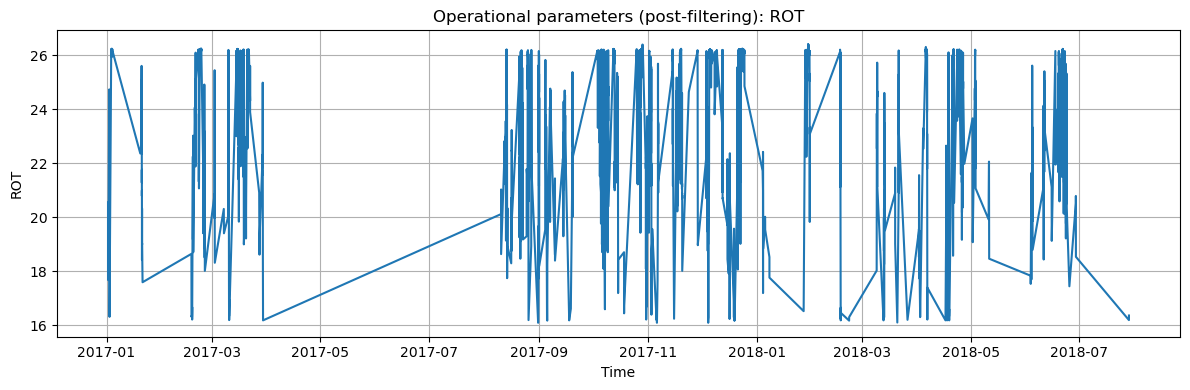

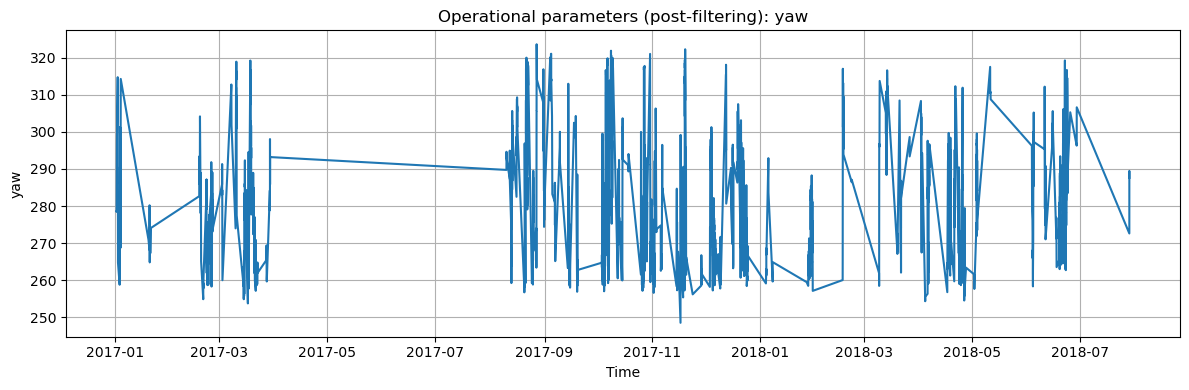

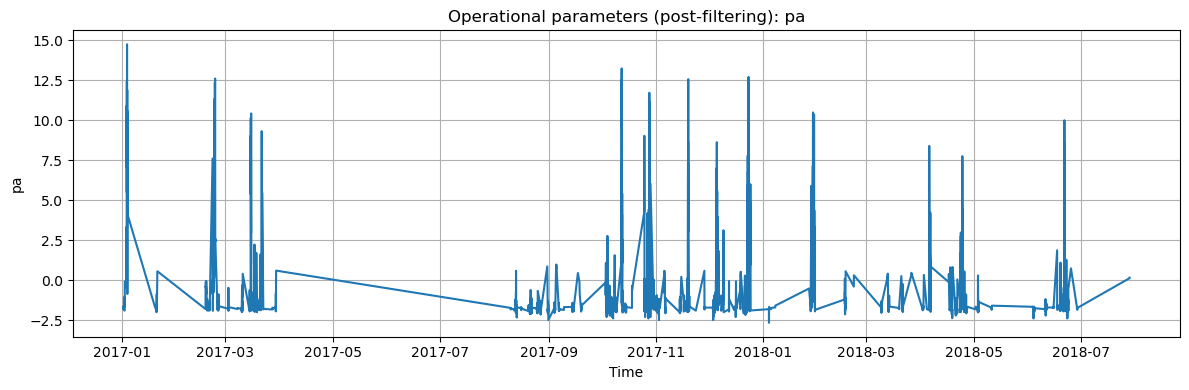

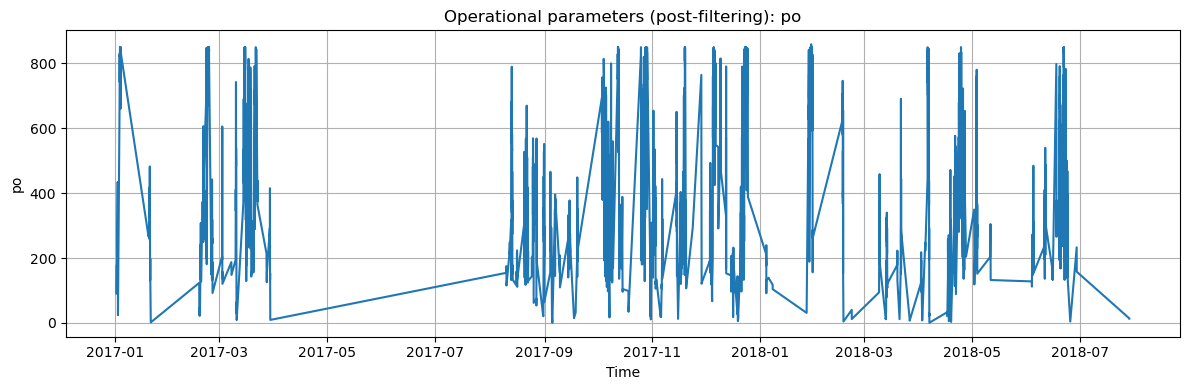

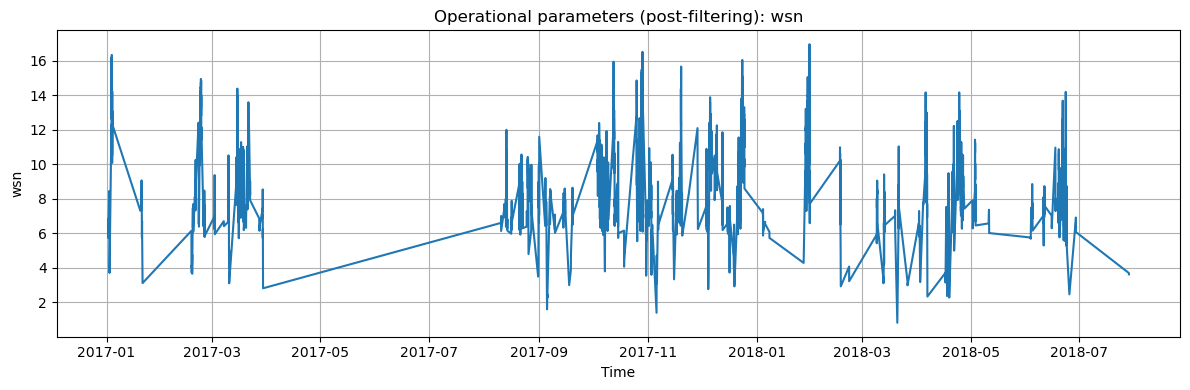

In [29]:
plot_columns(final_df, meteo_cols, "Wind direction at 41m (post-filtering)")

plot_columns(final_df, operational_cols, "Operational parameters (post-filtering)")

Load plotting function to check for odd values.

In [21]:
def load_plot(df_plot: pd.DataFrame, cols: list[str], title: str, ylabel: str, colors: list[str]):

    plt.figure(figsize=(14, 8))
    labels = ["Mean", "Stdev", "Min", "Max", "DEL3", "DEL6", "DEL9", "DEL12"]
    for col, lab, color in zip(cols, labels, colors):
        if col in df_plot.columns:

            # mask out-of-range values
            series = df_plot[col].where(abs(df_plot[col]) <= 1e4, np.nan)
            plt.plot(df_plot["rname"], series, label=f"{lab} ({col})", linewidth=0.7, color = color)

    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

From a first visualization, there are some values clearly out of range so an upper boundary is defined. 

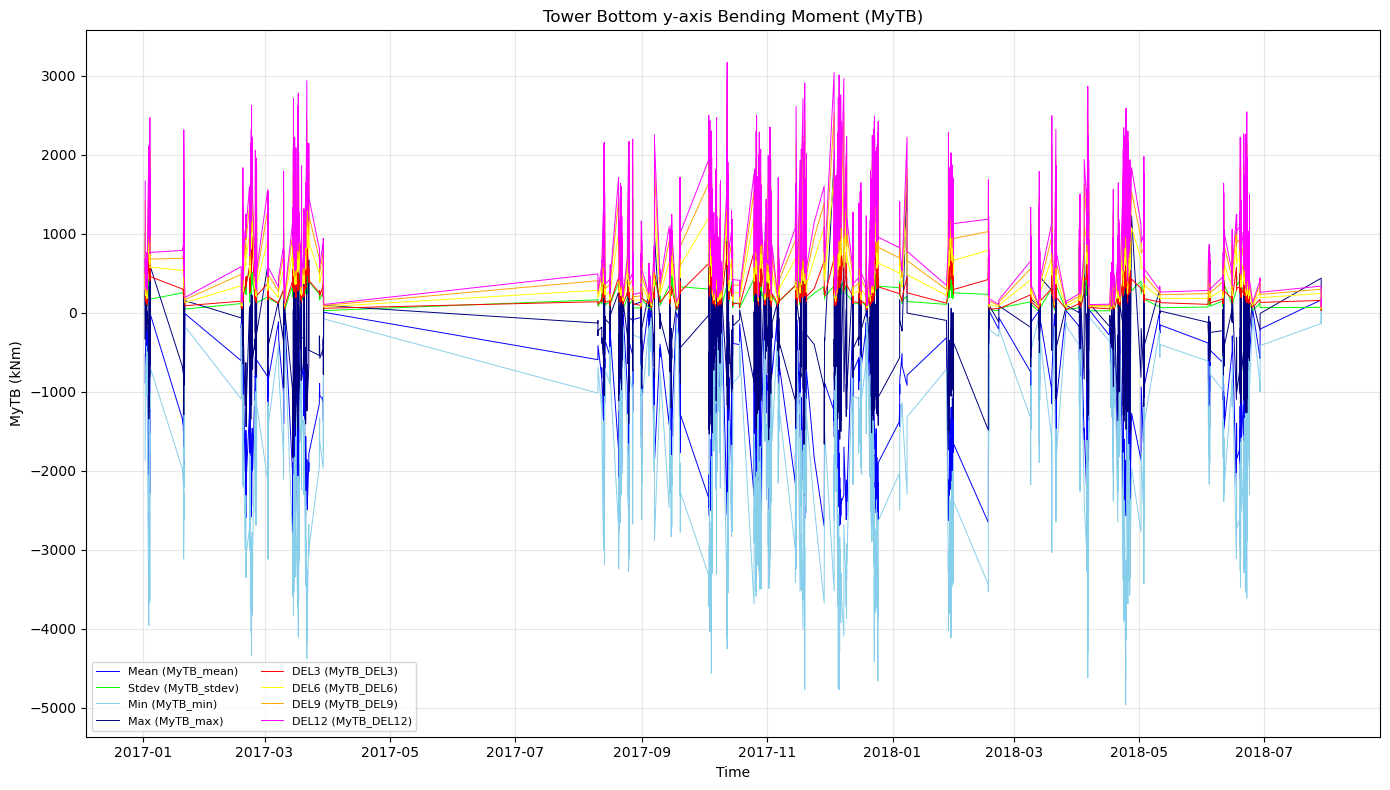

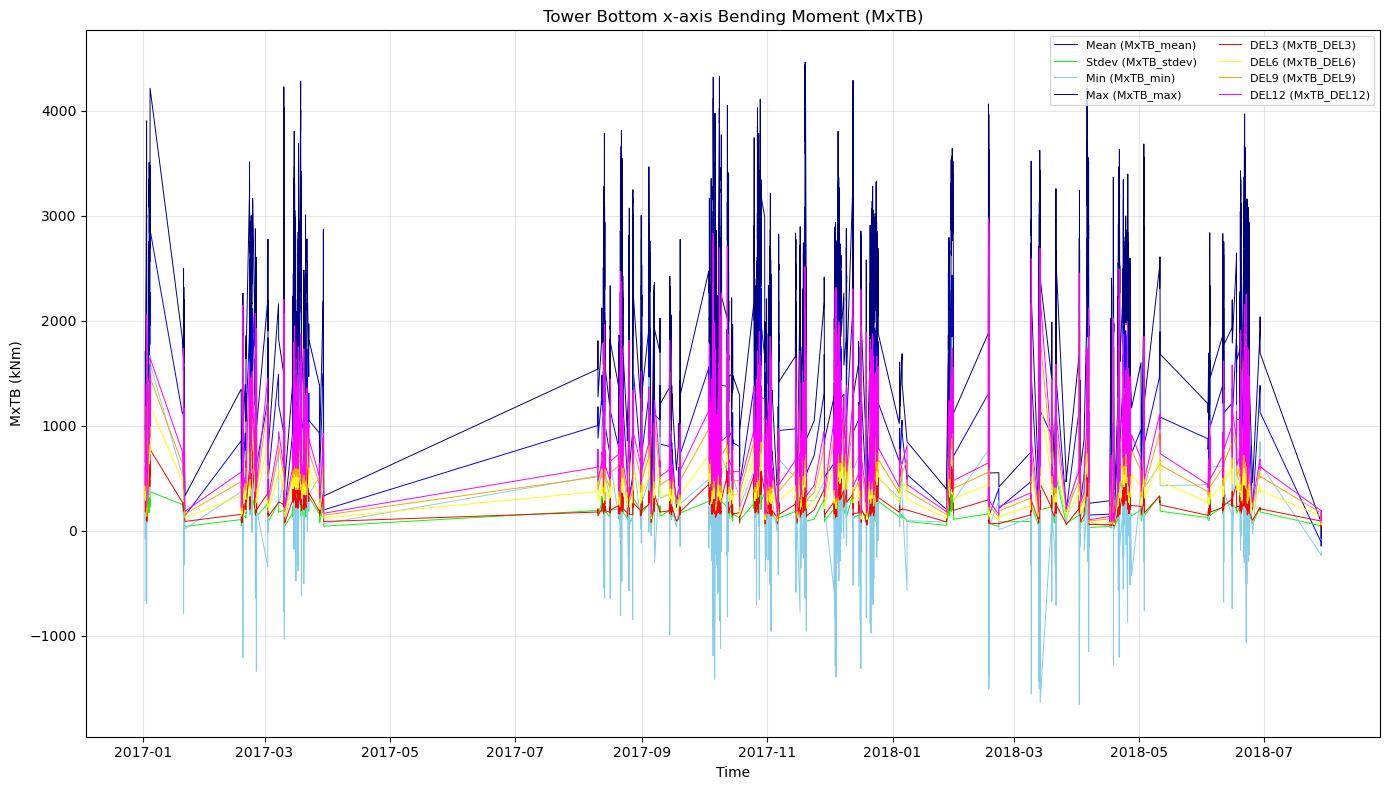

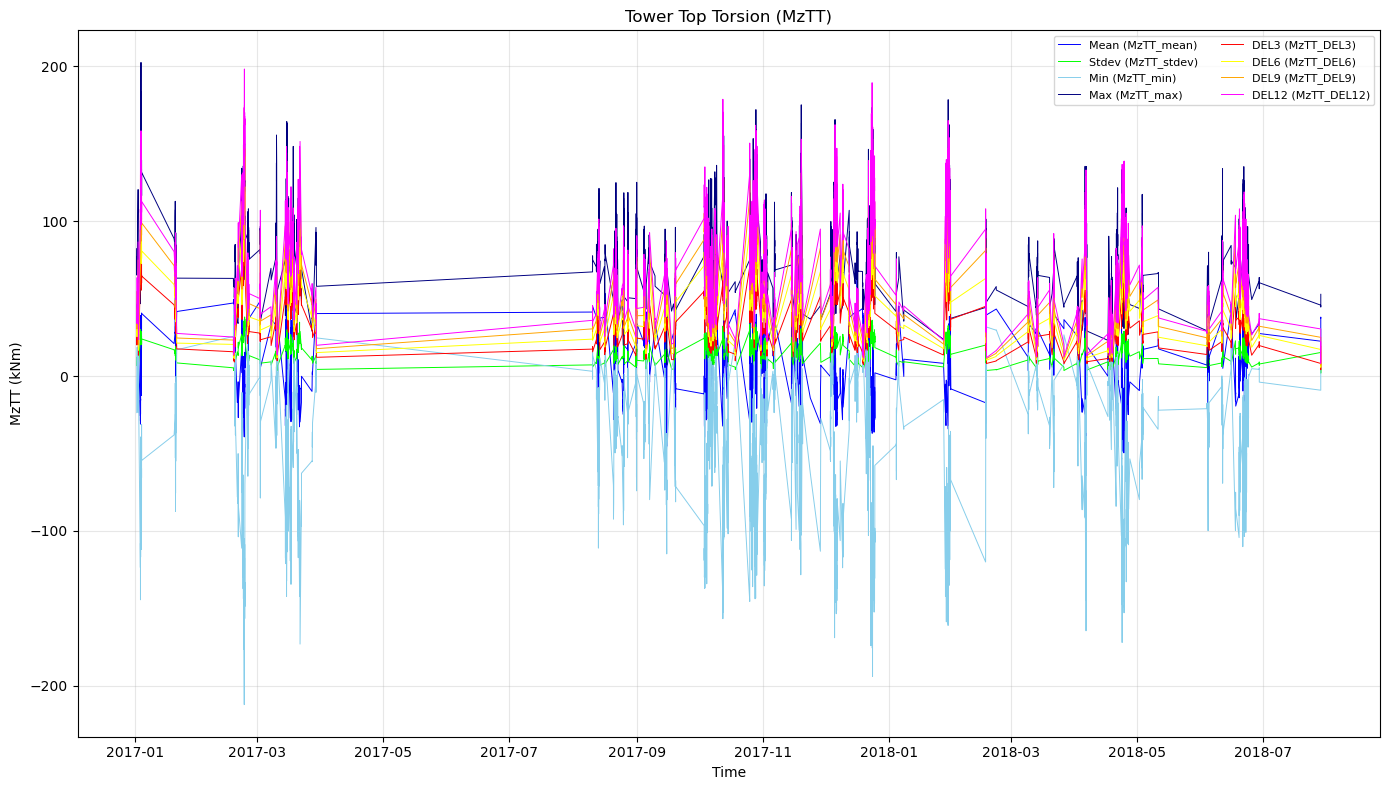

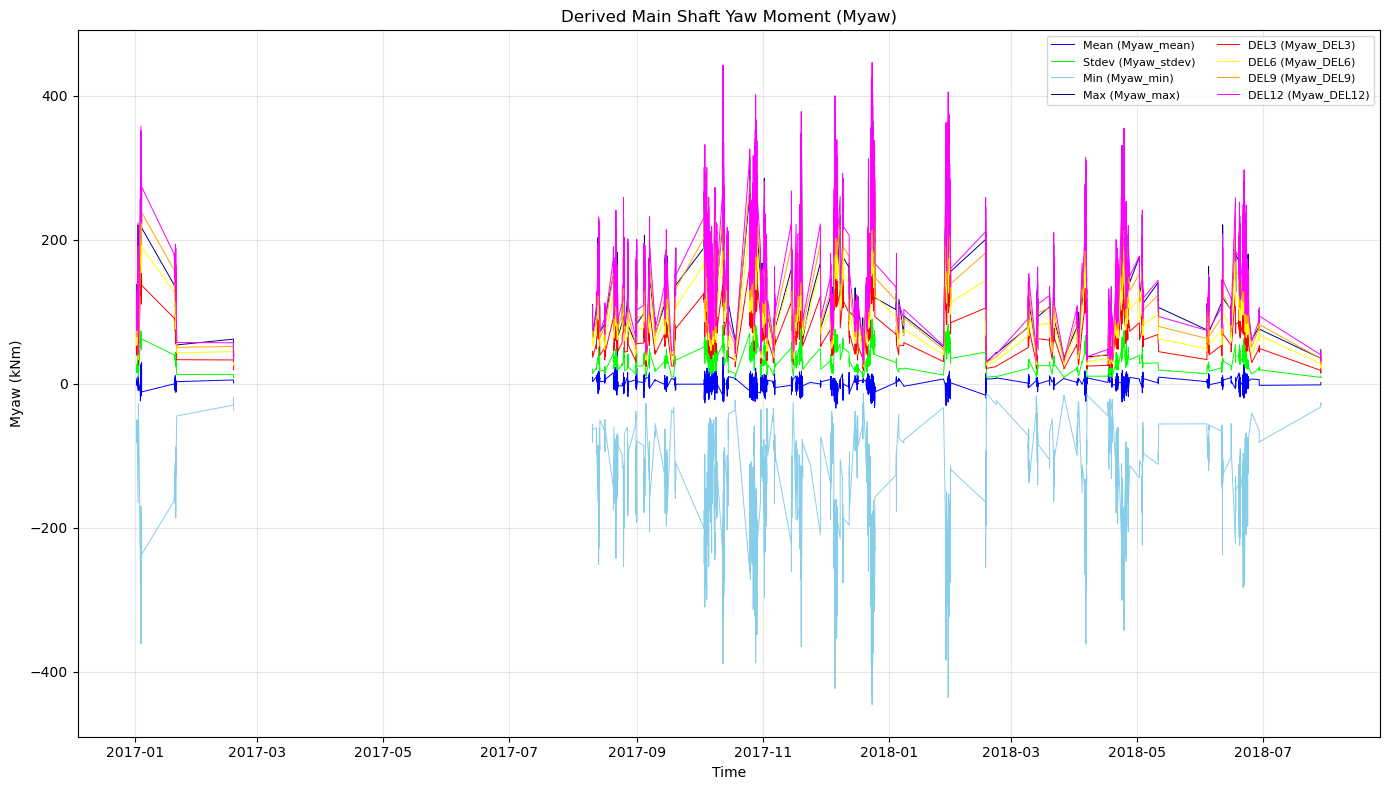

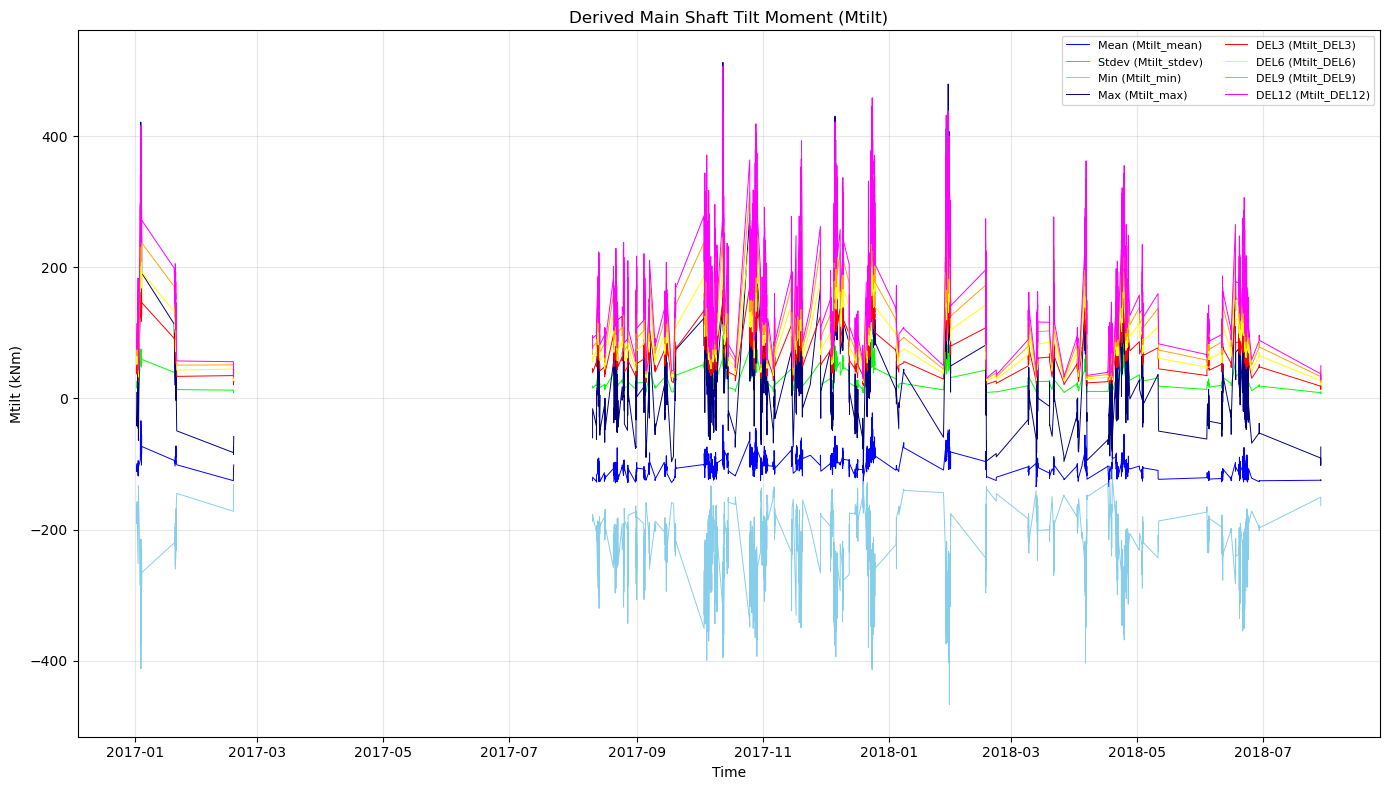

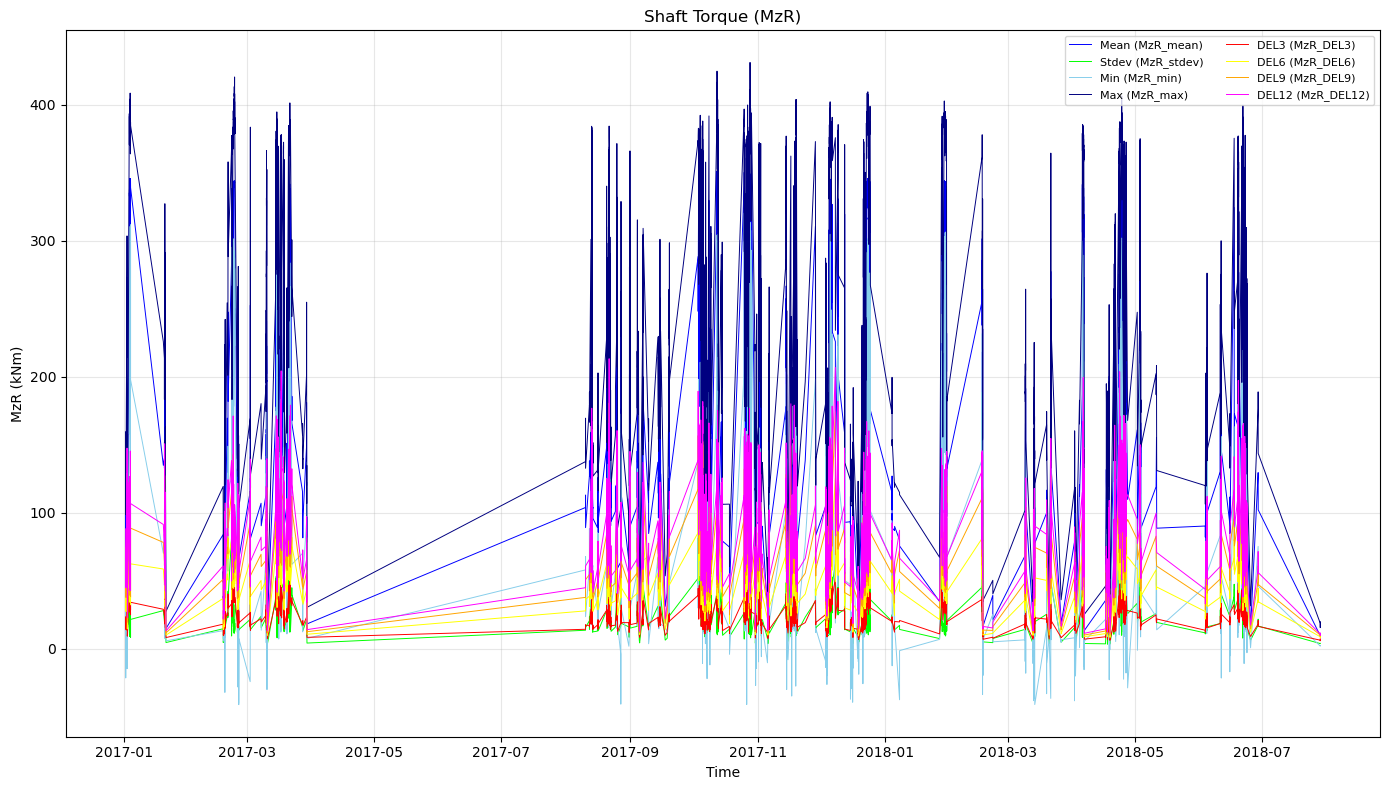

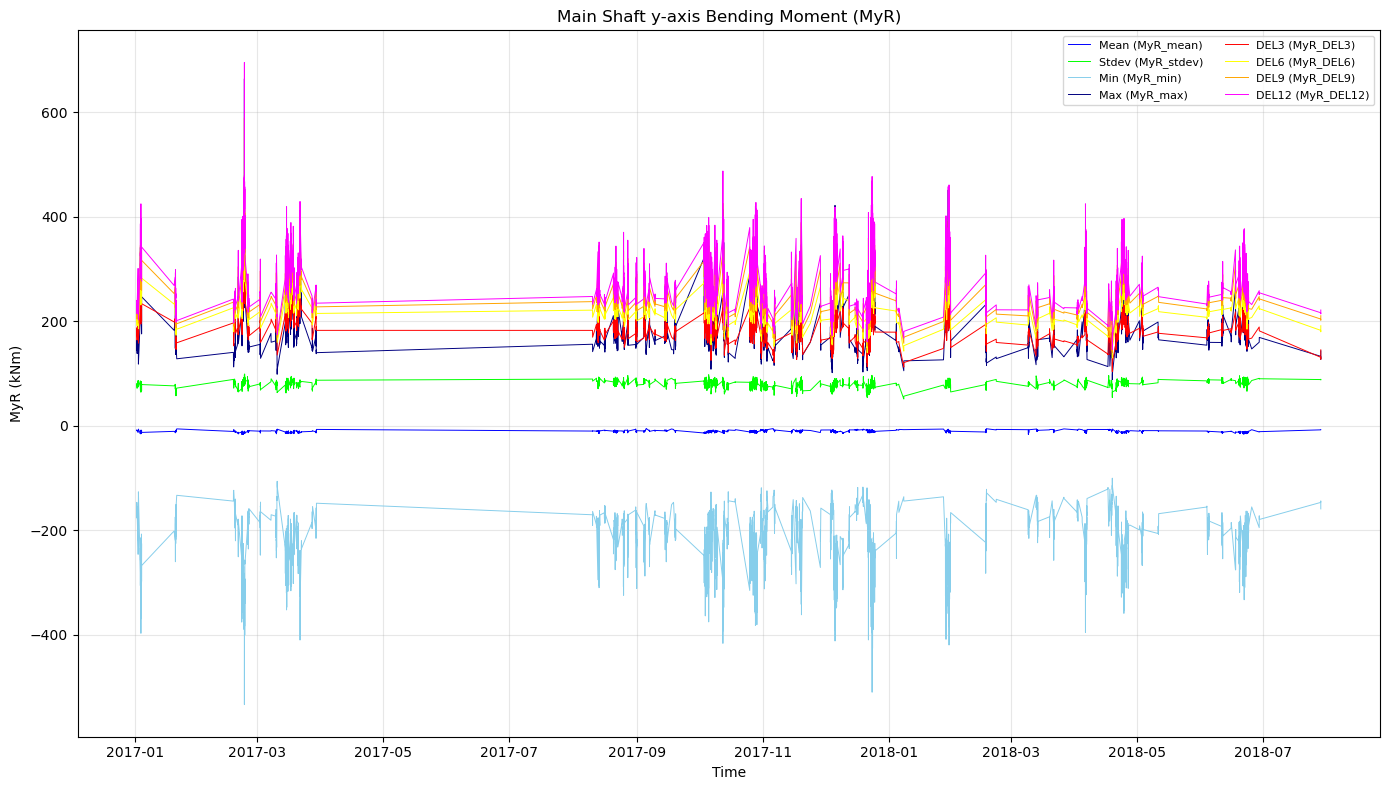

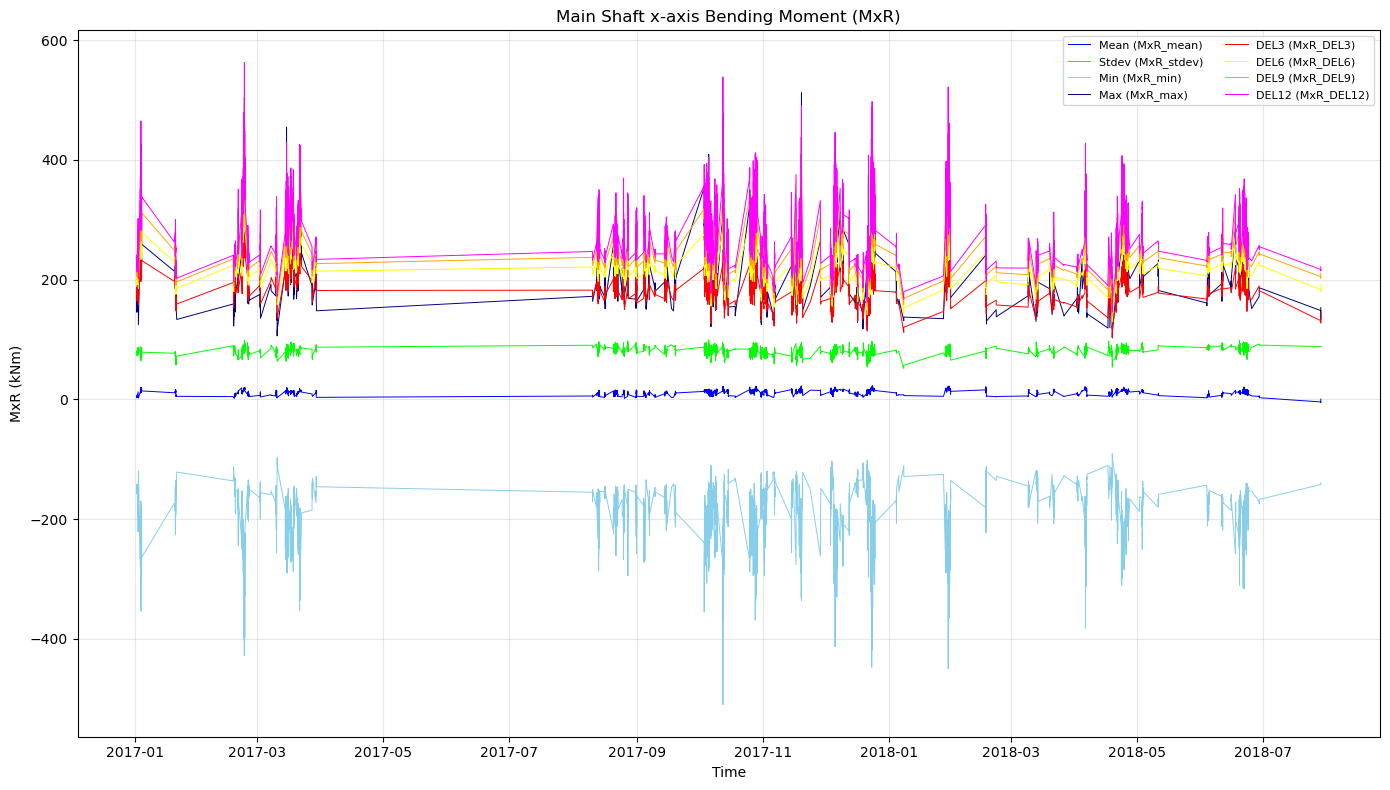

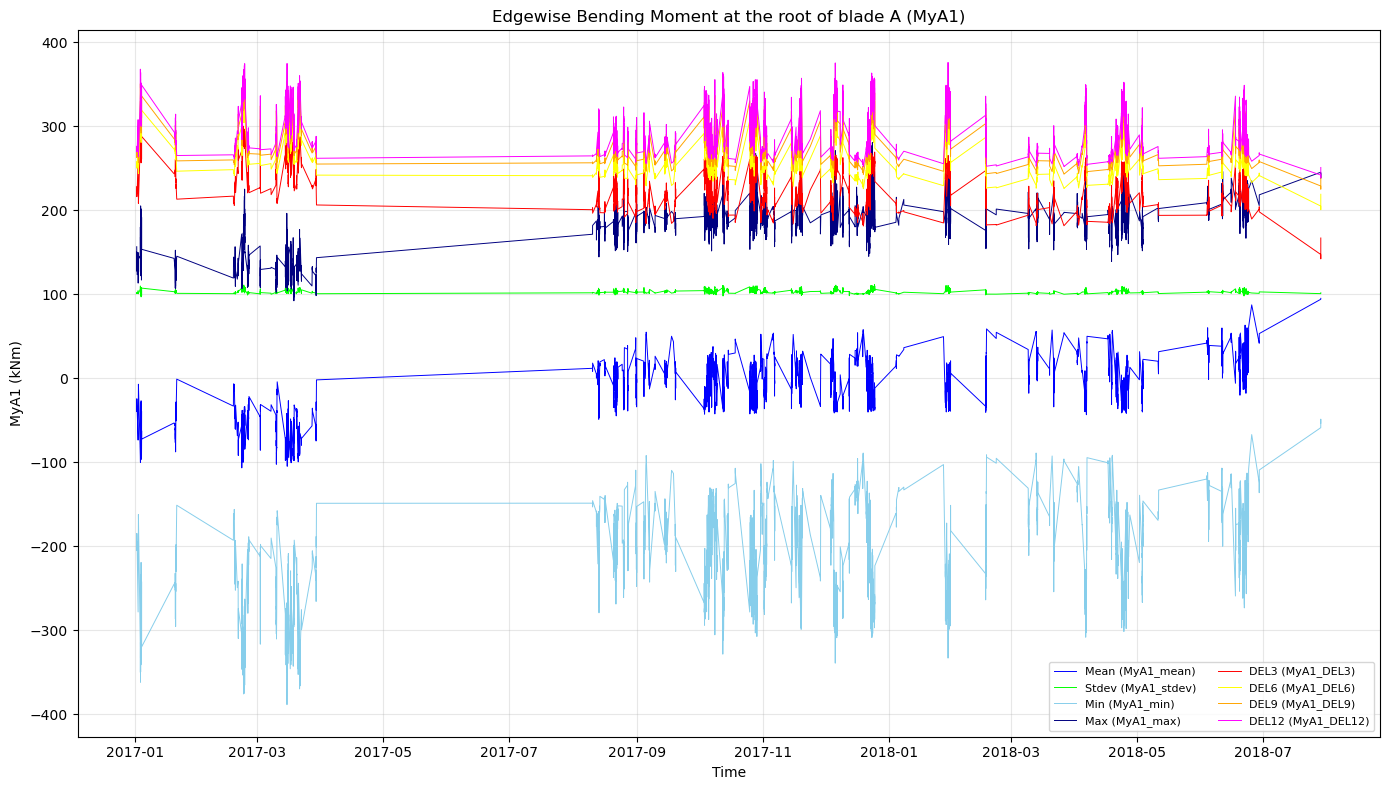

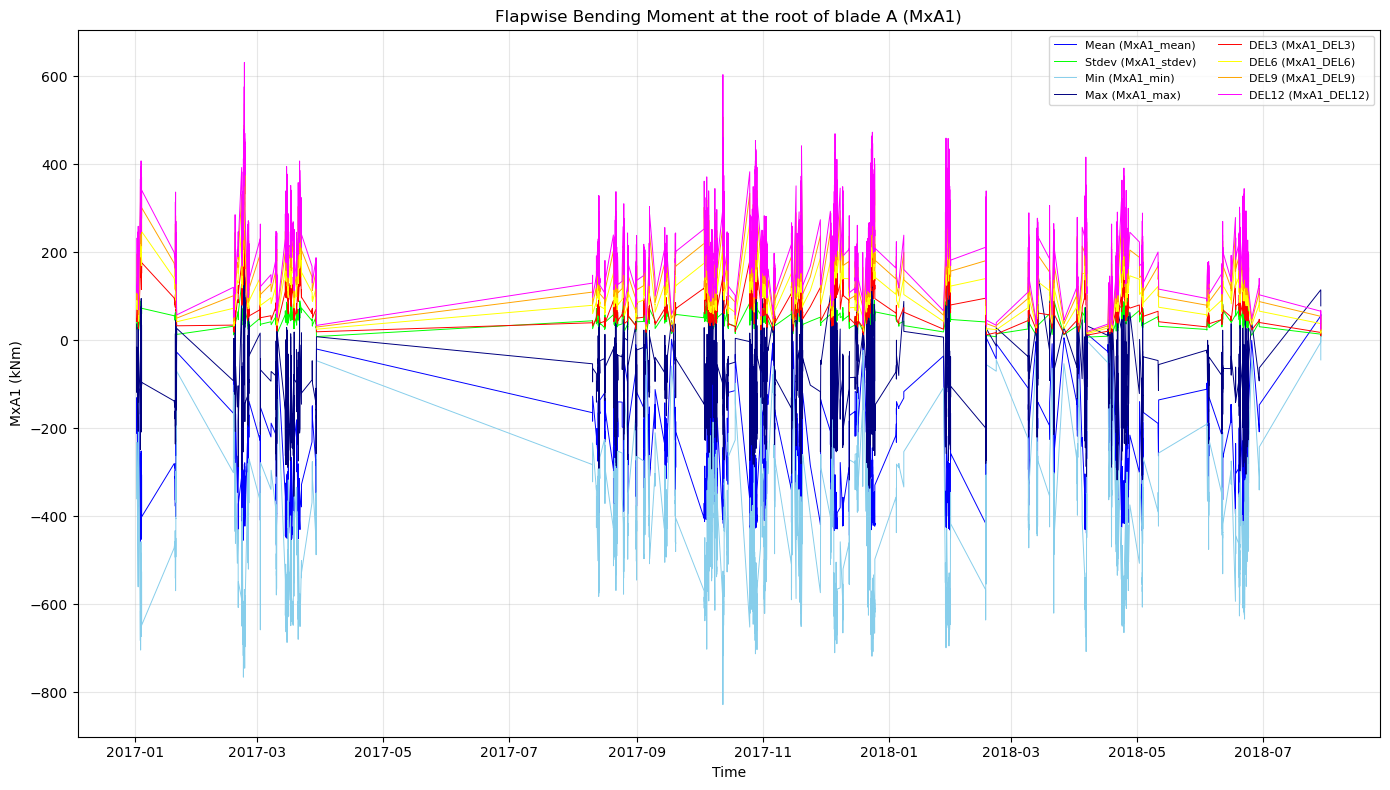

In [22]:
load_plot(
    final_df,
    ['MyTB_mean', 'MyTB_stdev', 'MyTB_min', 'MyTB_max', 'MyTB_DEL3', 'MyTB_DEL6', 'MyTB_DEL9', 'MyTB_DEL12'],
    "Tower Bottom y-axis Bending Moment (MyTB)",
    "MyTB (kNm)",
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['MxTB_mean', 'MxTB_stdev', 'MxTB_min', 'MxTB_max', 'MxTB_DEL3', 'MxTB_DEL6', 'MxTB_DEL9', 'MxTB_DEL12'],
    "Tower Bottom x-axis Bending Moment (MxTB)",
    "MxTB (kNm)",
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['MzTT_mean', 'MzTT_stdev', 'MzTT_min', 'MzTT_max', 'MzTT_DEL3', 'MzTT_DEL6', 'MzTT_DEL9', 'MzTT_DEL12'],
    "Tower Top Torsion (MzTT)",
    "MzTT (kNm)",
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['Myaw_mean', 'Myaw_stdev', 'Myaw_min', 'Myaw_max', 'Myaw_DEL3', 'Myaw_DEL6', 'Myaw_DEL9', 'Myaw_DEL12'],
    "Derived Main Shaft Yaw Moment (Myaw)",
    "Myaw (kNm)",
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['Mtilt_mean', 'Mtilt_stdev', 'Mtilt_min', 'Mtilt_max', 'Mtilt_DEL3', 'Mtilt_DEL6', 'Mtilt_DEL9', 'Mtilt_DEL12'],
    "Derived Main Shaft Tilt Moment (Mtilt)",
    "Mtilt (kNm)",
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['MzR_mean', 'MzR_stdev', 'MzR_min', 'MzR_max', 'MzR_DEL3', 'MzR_DEL6', 'MzR_DEL9', 'MzR_DEL12'],
    'Shaft Torque (MzR)',
    'MzR (kNm)',
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['MyR_mean', 'MyR_stdev', 'MyR_min', 'MyR_max', 'MyR_DEL3', 'MyR_DEL6', 'MyR_DEL9', 'MyR_DEL12'],
    "Main Shaft y-axis Bending Moment (MyR)",
    "MyR (kNm)",
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['MxR_mean', 'MxR_stdev', 'MxR_min', 'MxR_max', 'MxR_DEL3', 'MxR_DEL6', 'MxR_DEL9', 'MxR_DEL12'],
    "Main Shaft x-axis Bending Moment (MxR)",
    "MxR (kNm)",
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['MyA1_mean', 'MyA1_stdev', 'MyA1_min', 'MyA1_max', 'MyA1_DEL3', 'MyA1_DEL6', 'MyA1_DEL9', 'MyA1_DEL12'],
    'Edgewise Bending Moment at the root of blade A (MyA1)',
    'MyA1 (kNm)',
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

load_plot(
    final_df,
    ['MxA1_mean', 'MxA1_stdev', 'MxA1_min', 'MxA1_max', 'MxA1_DEL3', 'MxA1_DEL6', 'MxA1_DEL9', 'MxA1_DEL12'],
    'Flapwise Bending Moment at the root of blade A (MxA1)',
    'MxA1 (kNm)',
    ['blue', 'lime', 'skyblue', 'navy', 'red', 'yellow', 'orange', 'magenta']
)

Wind speed bins definition

In [23]:
bins = np.arange(0, 20, 1)
labels = (bins[:-1] + bins[1:]) / 2  # midpoints of bins

final_df['bin'] = pd.cut(final_df['Wsp_44m'], bins=bins, labels=labels)
final_df['bin']

0        6.5
1        6.5
2        6.5
3        6.5
4        5.5
        ... 
24341    6.5
24342    6.5
24442    1.5
24443    1.5
24444    2.5
Name: bin, Length: 5310, dtype: category
Categories (19, float64): [0.5 < 1.5 < 2.5 < 3.5 ... 15.5 < 16.5 < 17.5 < 18.5]

Average statistics for each channel for each bin.

In [24]:
bin_means = final_df.groupby('bin').mean(numeric_only=True)
bin_means

C:\Users\user\AppData\Local\Temp\ipykernel_2368\203331541.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = final_df.groupby('bin').mean(numeric_only=True)


,Wsp_44m,Wsp_44m_stdev,Wdir_41m,ROT,yaw,pa,po,wsn,MyTB_mean,MyTB_stdev,...,MyA1_DEL9,MyA1_DEL12,MxA1_mean,MxA1_stdev,MxA1_min,MxA1_max,MxA1_DEL3,MxA1_DEL6,MxA1_DEL9,MxA1_DEL12
bin,,,,,,,,,,,,,,,,,,,,,
0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.5,1.550000,0.395000,289.450000,16.200000,281.055000,0.140000,13.700000,3.700000,145.144500,44.611800,...,227.144500,240.325500,57.111900,10.822200,15.741240,97.694750,13.952200,26.945650,37.678650,45.482500
2.5,2.675000,0.540000,274.710000,16.290000,278.985000,0.500000,7.975000,2.955000,18.121800,53.724550,...,244.417000,254.616500,21.959950,23.952550,-29.216150,66.971550,23.082100,37.357300,48.403300,56.126600
3.5,3.543269,0.244423,291.533654,16.351731,288.017500,0.345769,13.738846,3.067115,-37.482990,42.659498,...,247.230904,256.111346,-7.525448,13.464908,-60.886709,27.475430,21.181425,33.110919,43.328308,50.869504
4.5,4.357045,0.219318,290.263864,16.525000,288.438182,-0.489091,40.042500,4.210455,-182.714400,62.577023,...,250.749227,259.312977,-47.704564,17.628881,-121.121859,0.239147,24.613282,43.443091,58.923016,69.807402
5.5,5.732427,0.472913,282.849515,18.621165,281.581165,-1.621456,109.253786,6.154175,-565.170002,136.165425,...,257.075087,265.629379,-128.688745,33.964985,-260.748194,-25.944431,46.258542,84.189058,114.253803,135.173194
6.5,6.570668,0.605772,284.451440,20.685563,284.130013,-1.602592,169.871322,6.692160,-725.130137,167.384600,...,261.693920,269.919933,-182.275963,41.461389,-323.258035,-58.565408,55.766387,96.953620,129.889430,153.046855
7.5,7.513698,0.775331,284.730455,22.600145,284.416725,-1.730217,258.166023,7.457634,-982.507009,213.314833,...,269.654754,278.141014,-248.291129,51.016764,-404.668867,-97.347020,67.832226,113.439116,151.038815,177.753213
8.5,8.483184,0.899598,284.678592,24.425285,284.404156,-1.870547,368.959117,8.361151,-1266.777538,235.559128,...,281.403568,290.687078,-317.502610,54.235966,-470.880989,-144.129025,77.495839,123.805991,162.356540,190.088387


Plotting function for both scattered values and bin averages.

In [ ]:
def plot_loads_vs_wind(df, bin_means, base_name):
    """
    base_name example: 'MyTB'
    expects columns like:
    MyTB_max, MyTB_mean, MyTB_min, MyTB_stdev
    """

    _, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # ---------------- TOP PLOT ----------------
    ax = axes[0]

    # Raw data (scatter-like lines)
    ax.plot(df["Wsp_44m"], df[f"{base_name}_max"], '.', alpha=0.2, label="Max (raw)", color='lightcoral')
    ax.plot(df["Wsp_44m"], df[f"{base_name}_mean"], '.', alpha=0.2, label="Mean (raw)", color='red')
    ax.plot(df["Wsp_44m"], df[f"{base_name}_min"], '.', alpha=0.2, label="Min (raw)", color='maroon')

    # Bin averages (clean lines)
    ax.plot(bin_means.index.astype(float), bin_means[f"{base_name}_max"], '-o', label="Max (bin avg)", color='navy')
    ax.plot(bin_means.index.astype(float), bin_means[f"{base_name}_mean"], '-o', label="Mean (bin avg)", color='blue')
    ax.plot(bin_means.index.astype(float), bin_means[f"{base_name}_min"], '-o', label="Min (bin avg)", color='skyblue')

    ax.set_ylabel("Load [kNm]")
    ax.set_title(f"{base_name} vs Wind Speed")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    # ---------------- BOTTOM PLOT ----------------
    ax = axes[1]

    # Raw std dev
    ax.plot(df["Wsp_44m"], df[f"{base_name}_stdev"], '.', alpha=0.2, label="Stdev (raw)")

    # Bin average std dev
    ax.plot(bin_means.index.astype(float), bin_means[f"{base_name}_stdev"], '-o', label="Stdev (bin avg)")

    ax.set_xlabel("Wind Speed [m/s]")
    ax.set_ylabel("Std Dev [kNm]")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()

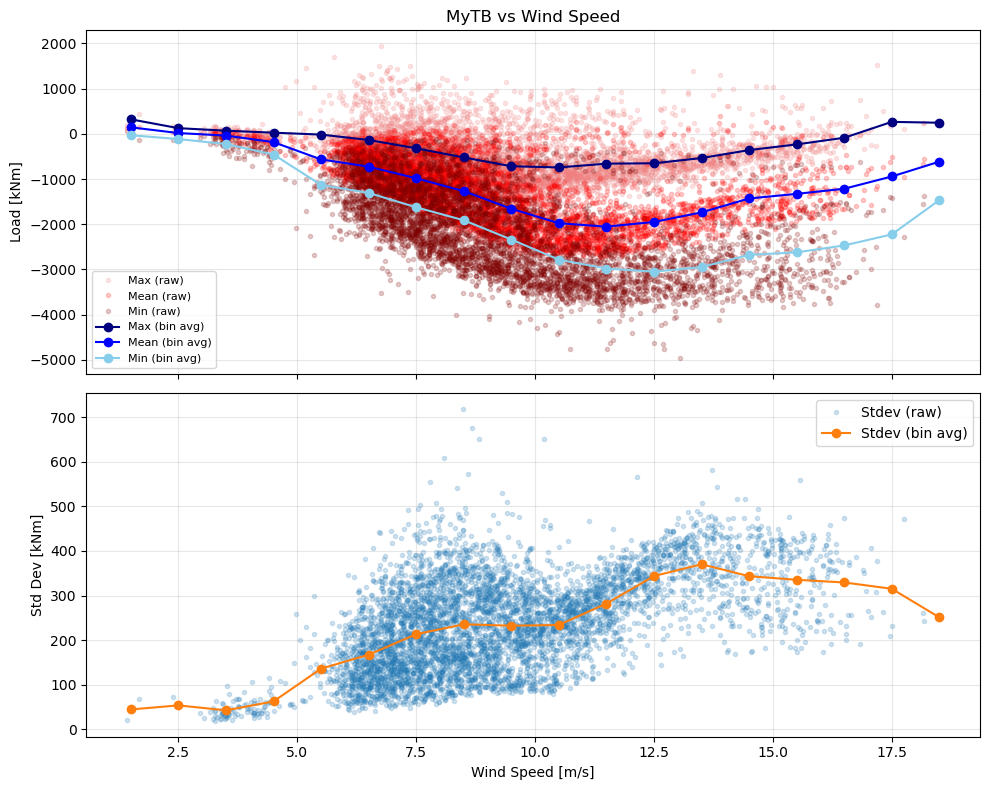

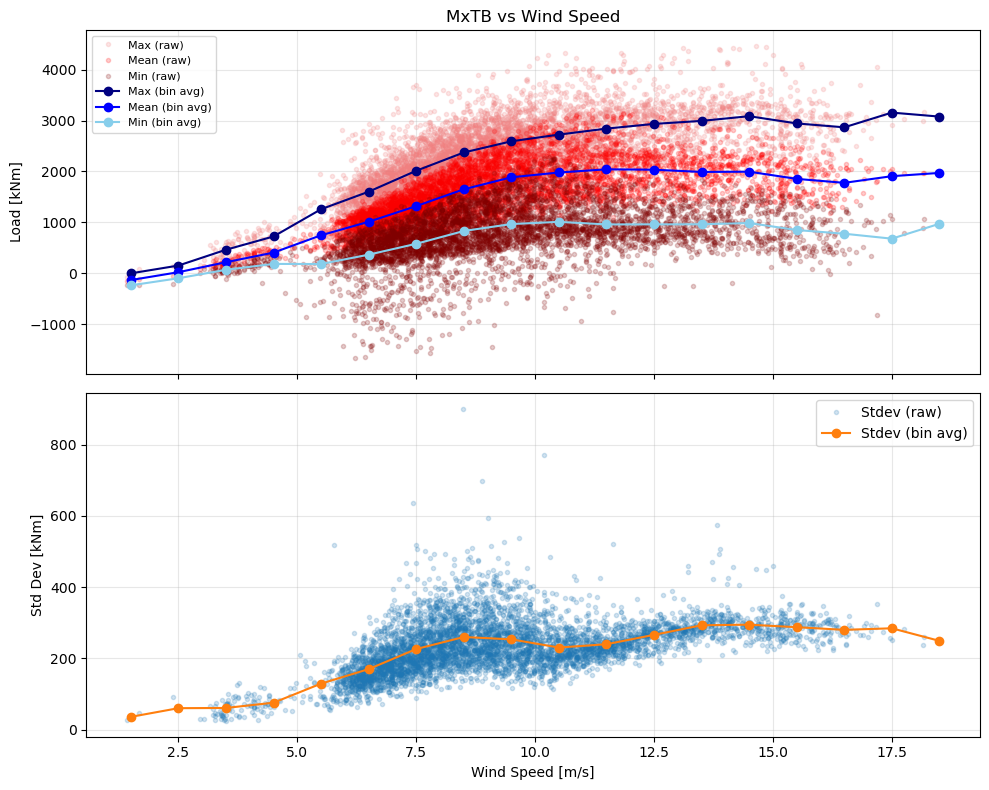

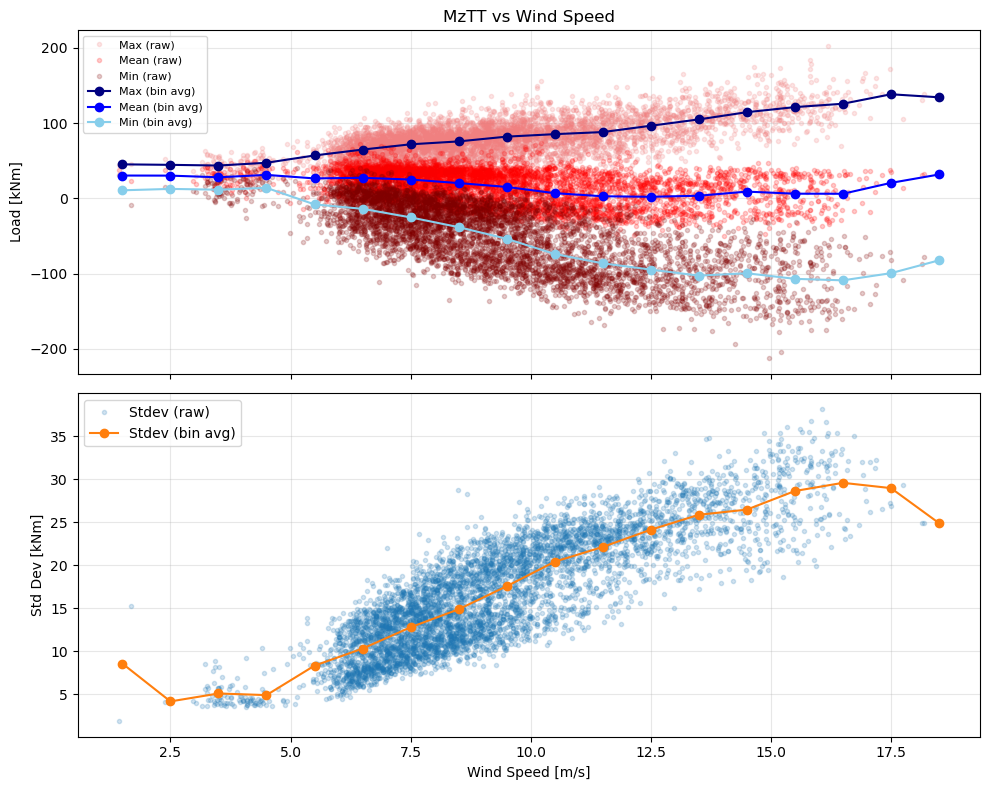

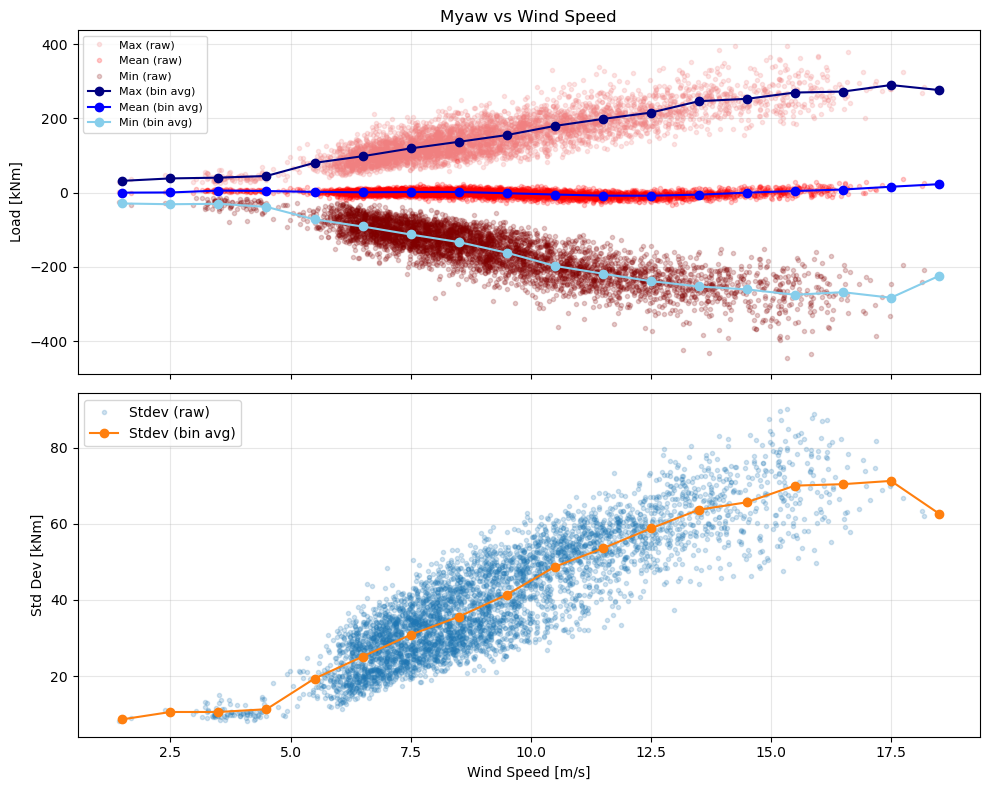

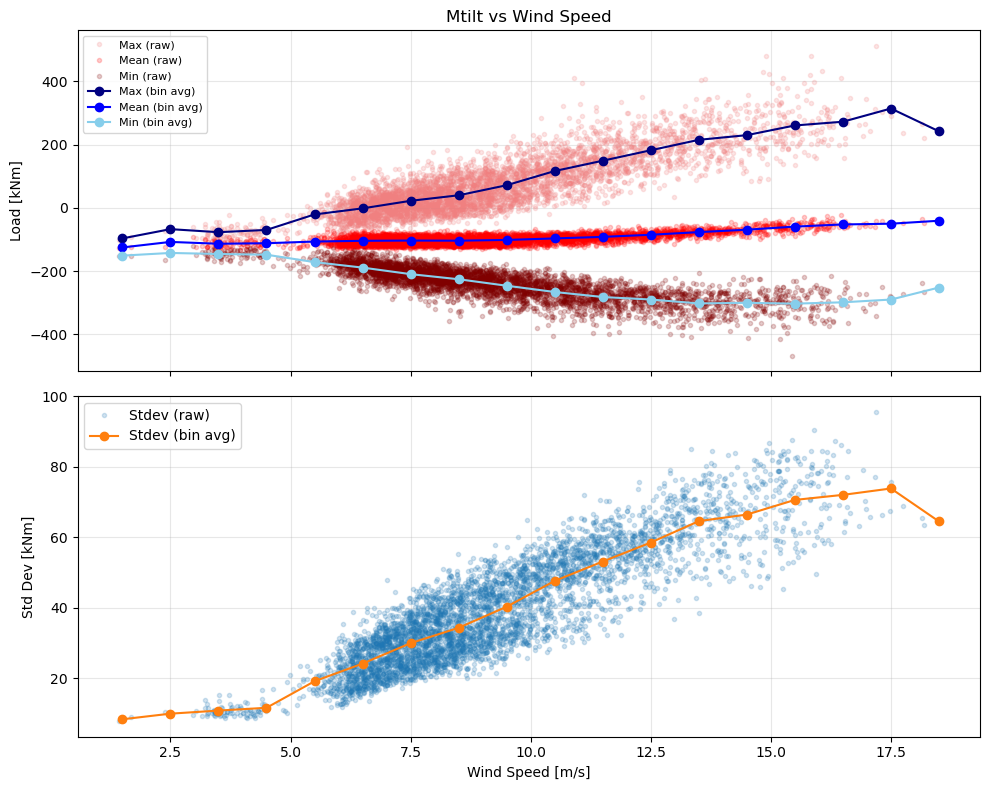

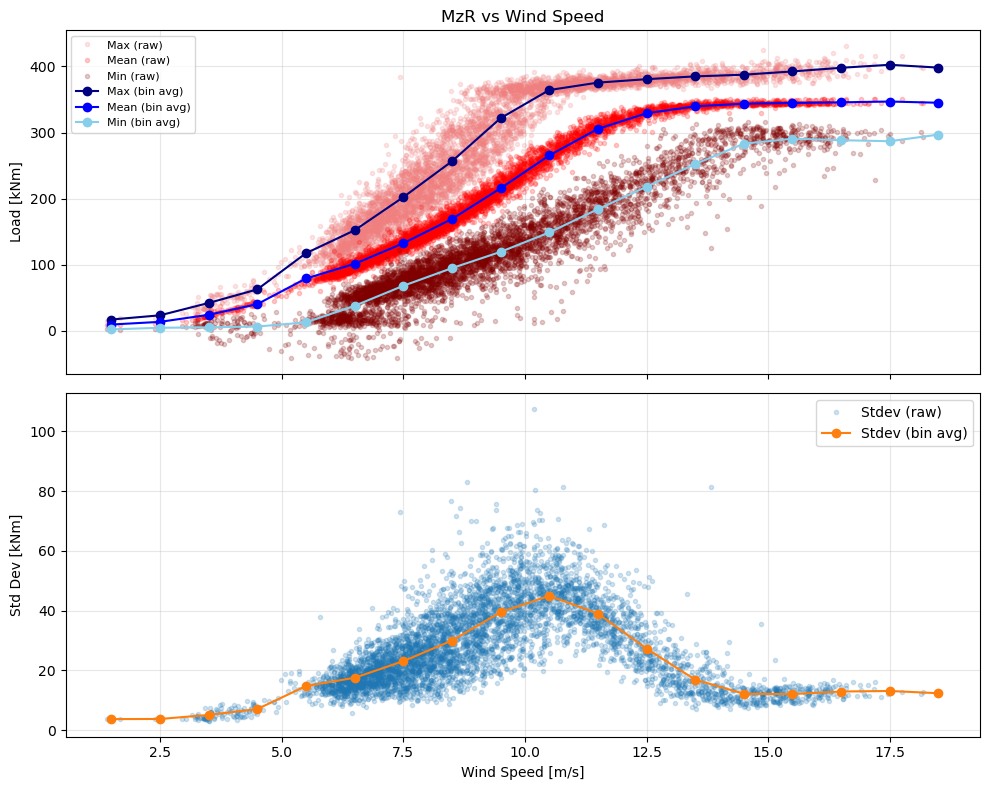

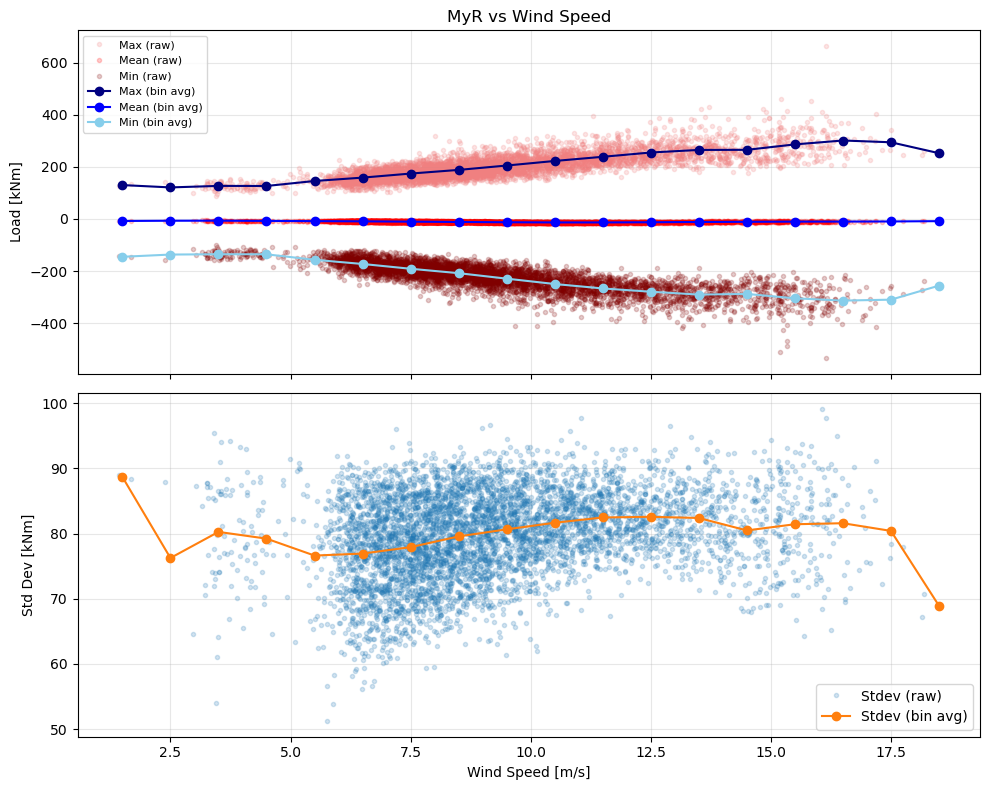

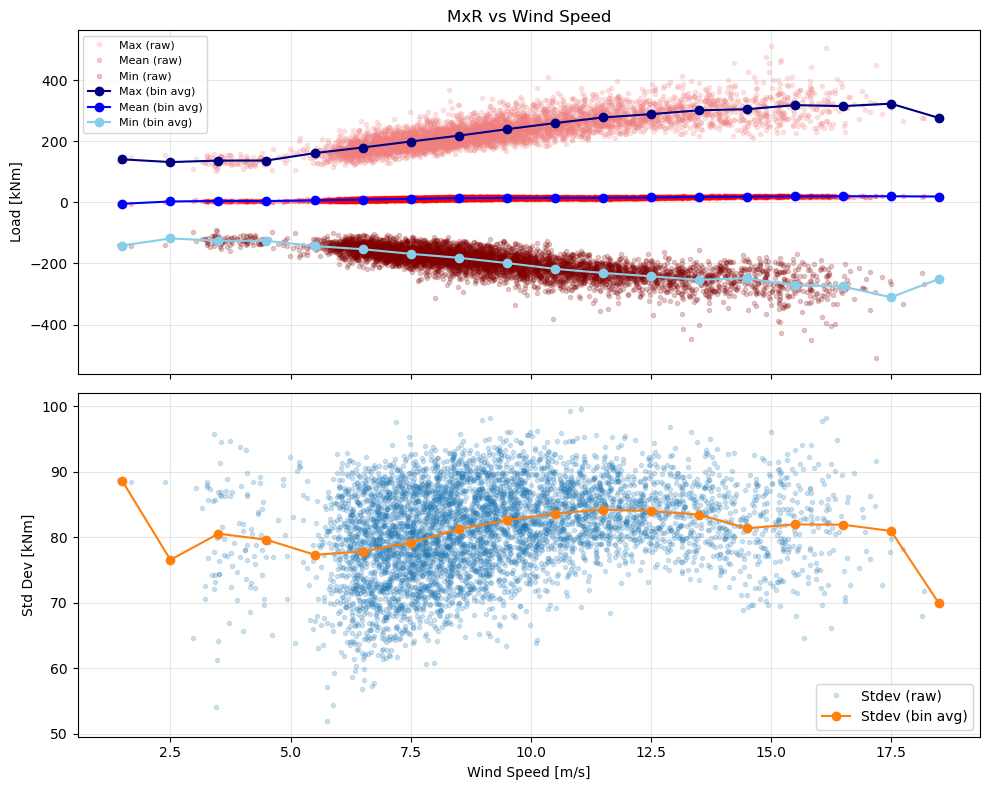

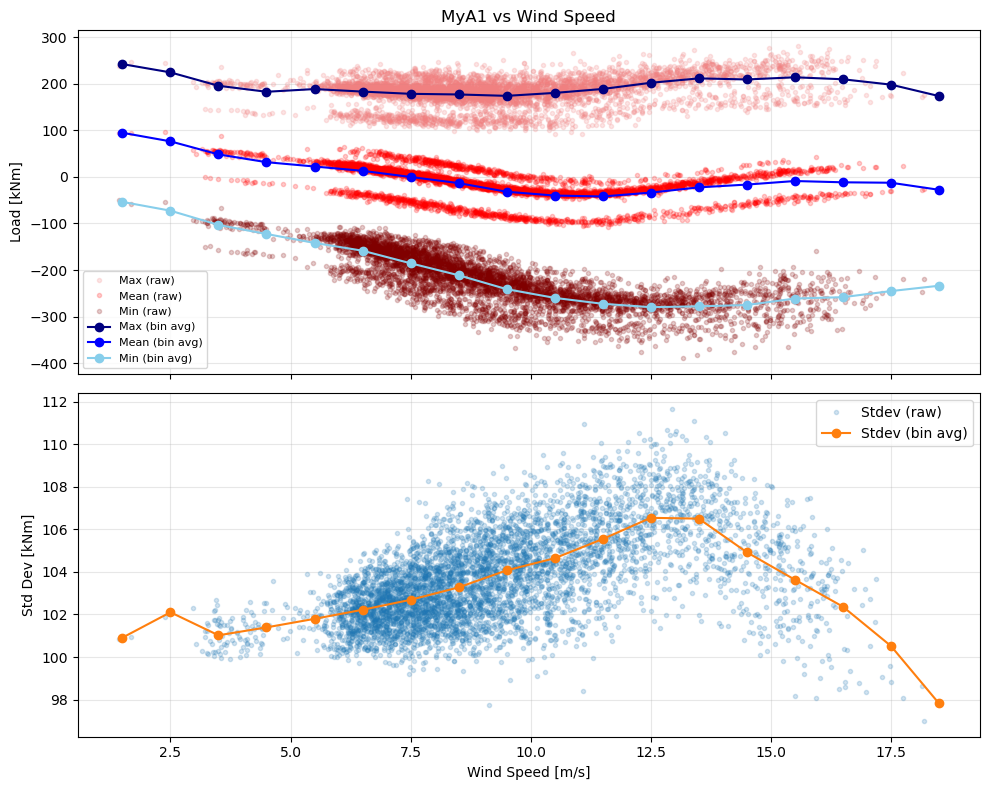

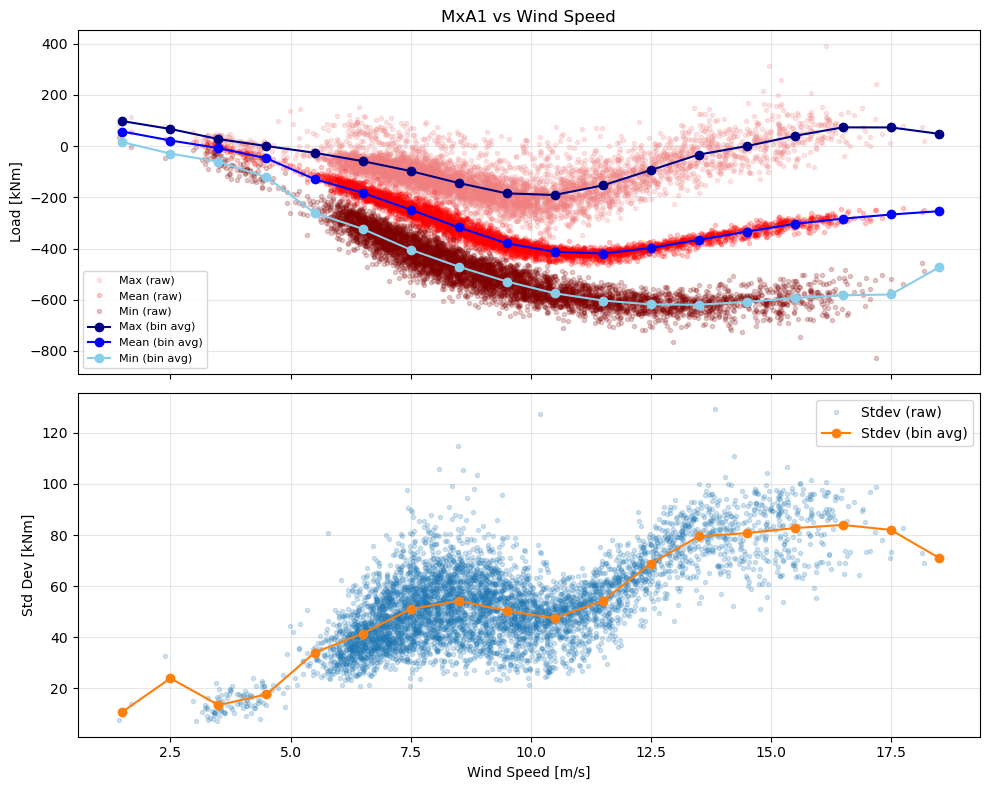

In [26]:
channels = ["MyTB", "MxTB", "MzTT", "Myaw", "Mtilt", "MzR", "MyR", "MxR", "MyA1", "MxA1"]  

for ch in channels:
    plot_loads_vs_wind(final_df, bin_means, ch)

Similar trends can be observed in edgewise bending moment ("three thick lines" in mean moments). It's unlikely to be a calibration problem (offset shift would've been detected when plotting time vs load) while it could be due to wind turbine operating conditions (e.g. starting or stopping, idling, ...). To check for that, the scatter below is proposed. 

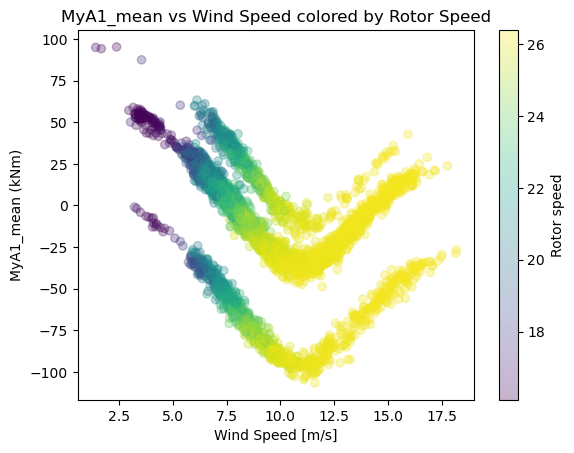

In [27]:
plt.scatter(final_df["Wsp_44m"], final_df["MyA1_mean"], c=final_df["ROT"], cmap="viridis", alpha=0.3)
plt.colorbar(label="Rotor speed")
plt.title("MyA1_mean vs Wind Speed colored by Rotor Speed")
plt.xlabel("Wind Speed [m/s]")
plt.ylabel("MyA1_mean (kNm)")
plt.show()

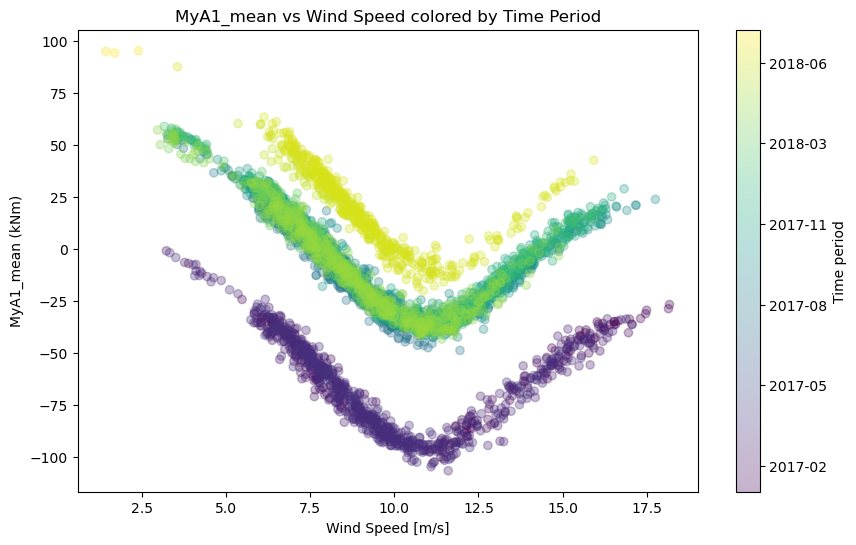

In [28]:
import matplotlib.dates as mdates

time_numeric = mdates.date2num(final_df['rname'])

plt.figure(figsize=(10, 6))
sc=plt.scatter(final_df["Wsp_44m"], final_df["MyA1_mean"], c=time_numeric, cmap="viridis", alpha=0.3)
cbar = plt.colorbar(sc, label="Time period")
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.title("MyA1_mean vs Wind Speed colored by Time Period")
plt.xlabel("Wind Speed [m/s]")
plt.ylabel("MyA1_mean (kNm)")
plt.show()

Since the three bands are very date-dependant, meaning that different bands were being "computed" at different times in measurement campaigns, it's likely to be a calibration issue. This doesn't exclude WT were operating under different conditions but, combining this result with the MyA1 vs wind speed colored by ROT, it's a very reasonable assumption. 

Approach now is to detect which subsets in final_df were affected and correct the calibration parameters, namely offset because the phenomenon happening along the dataset is an offset drift.

Strategy is the following:
- splitting the subset into smaller dataframes (e.g. each subset assigned to a month)
- identify reference load for comparisons
- estimate offset correction (by simply evaluating the difference between subset offset and reference load) and apply the correction

In [46]:
final_df["period"] = final_df["rname"].dt.to_period("M")

ref_df = final_df[(final_df["Wsp_44m"] > 8) & (final_df["Wsp_44m"] < 10)]

offsets = ref_df.groupby("period")["MyA1_mean"].mean()
offsets

period
2017-01   -70.965743
2017-02   -69.017672
2017-03   -79.648892
2017-08   -20.919345
2017-09    -7.428412
2017-10   -16.634765
2017-11   -14.021068
2017-12   -18.036301
2018-01   -25.925211
2018-02   -18.910905
2018-03    -5.966721
2018-04   -18.407249
2018-05   -15.236756
2018-06    16.555446
Freq: M, Name: MyA1_mean, dtype: float64

Visualizing offsets

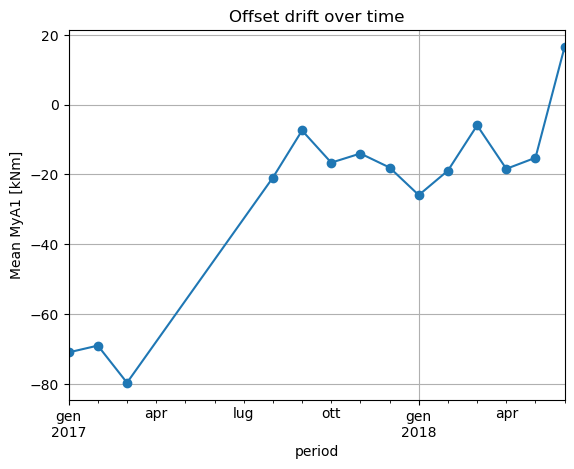

In [44]:
offsets.plot(marker='o', title="Offset drift over time")
plt.ylabel("Mean MyA1 [kNm]")
plt.grid()
plt.show()

Estimate and apply offset correction

In [38]:
ref_value = offsets.iloc[0]

corrections = offsets - ref_value

df_corrected = final_df.copy()

for period, corr in corrections.items():
    mask = df_corrected["period"] == period
    df_corrected.loc[mask, "MyA1_mean"] -= corr

ref_value, corrections

(-70.96574285714286,
 period
 2017-01     0.000000
 2017-02     1.948071
 2017-03    -8.683150
 2017-08    50.046398
 2017-09    63.537330
 2017-10    54.330977
 2017-11    56.944675
 2017-12    52.929442
 2018-01    45.040532
 2018-02    52.054838
 2018-03    64.999022
 2018-04    52.558494
 2018-05    55.728987
 2018-06    87.521189
 Freq: M, Name: MyA1_mean, dtype: float64)

In [48]:
ref_offset = 321.8

new_offsets = ref_offset - corrections
print(new_offsets)

period
2017-01    321.800000
2017-02    319.851929
2017-03    330.483150
2017-08    271.753602
2017-09    258.262670
2017-10    267.469023
2017-11    264.855325
2017-12    268.870558
2018-01    276.759468
2018-02    269.745162
2018-03    256.800978
2018-04    269.241506
2018-05    266.071013
2018-06    234.278811
Freq: M, Name: MyA1_mean, dtype: float64


To check main shaft torque (MzR) using active power, the formula $P = M \cdot \omega$ could be used. The conversion from $RPM$ to $\frac{rad}{s}$ must be before applied.

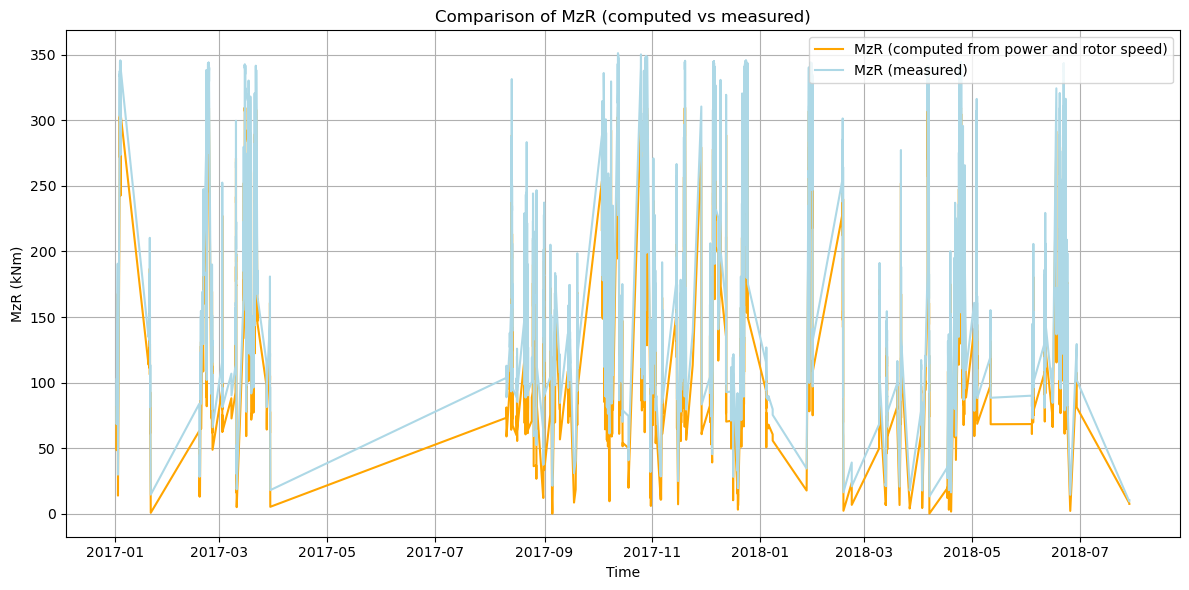

In [52]:
final_df['omega'] = final_df['ROT'] * (2 * np.pi / 60)  # convert RPM to rad/s
final_df['MzR_computed'] = final_df['po'] / final_df['omega']  

plt.figure(figsize=(12, 6))
plt.plot(final_df['rname'], final_df['MzR_computed'], label="MzR (computed from power and rotor speed)", color='orange')
plt.plot(final_df['rname'], final_df['MzR_mean'], label="MzR (measured)", color='lightblue')
plt.title("Comparison of MzR (computed vs measured)")
plt.xlabel("Time")
plt.ylabel("MzR (kNm)")
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

It is reasonable that there's some difference because we are not accounting for drivetrain efficiency but the trends should be comparable.